# 🖋️ Keystroke Dynamics User Identification

## 📌 Project Overview
This project explores **keystroke dynamics** — the unique way individuals type — as a form of biometric identification. Using the **DSL-StrongPasswordData** benchmark dataset, we trained machine learning models to identify users based on their typing patterns.  

The task is a **50-class classification problem** (50 users), making it more challenging than binary authentication.  

---

## 📂 Dataset
- **Source**: [DSL-StrongPasswordData](https://www.cs.cmu.edu/~keystroke/)  
- **Samples**: ~400 per user  
- **Classes**: 50 users (subjects `s001`–`s050`)  
- **Features**: Keystroke timing features (Hold times, Up-Down, Down-Down intervals, etc.)  

---

## ⚙️ Approach
1. **Data Preprocessing**
   - Loaded dataset, checked missing values (none).  
   - Encoded user labels with `LabelEncoder`.  

2. **Feature Selection**
   - Used XGBoost feature importance to extract top keystroke features.  

3. **Model Training**
   - Models trained: Logistic Regression, Random Forest, XGBoost.  
   - Hyperparameter tuning for XGBoost (regularization: L1, L2).  

4. **Evaluation**
   - Accuracy, precision, recall, F1-score.  
   - Confusion matrix visualization.  
   - Per-user performance analysis.  

---

## 📊 Results
| Model                | Accuracy |
|-----------------------|----------|
| Logistic Regression   | ~66%     |
| Random Forest         | ~91.0%   |
| **XGBoost (final)**   | **91.1%**|

### Key Findings
- Tree-based models (RF, XGBoost) significantly outperform linear models.  
- Most users have **F1-scores > 0.9**, though a few users (like subjects 25 & 26) are harder to classify (~0.73–0.77).  
- Confusion matrix shows a **strong diagonal**, confirming reliable identification.  

---

## 🖼️ Visualizations
- Feature importance (Top 20 features by XGBoost).  
- Confusion Matrix (50x50).  
- Per-user F1 score bar chart.  

---

## 🚀 Future Work
- Explore **deep learning models (RNNs/LSTMs)** to capture sequential typing patterns.  
- Test cross-session or cross-device performance for real-world robustness.  
- Apply dimensionality reduction (PCA/t-SNE) for visualization of user clusters.  

---

## Load the Dataset

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input/keystroke-dynamics-benchmark-data-set'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/keystroke-dynamics-benchmark-data-set/DSL-StrongPasswordData.csv


## Dataset Details

In [2]:
file_path = '/kaggle/input/keystroke-dynamics-benchmark-data-set/DSL-StrongPasswordData.csv'
df = pd.read_csv(file_path)

# View Sample
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (20400, 34)
  subject  sessionIndex  rep  H.period  DD.period.t  UD.period.t     H.t  \
0    s002             1    1    0.1491       0.3979       0.2488  0.1069   
1    s002             1    2    0.1111       0.3451       0.2340  0.0694   
2    s002             1    3    0.1328       0.2072       0.0744  0.0731   
3    s002             1    4    0.1291       0.2515       0.1224  0.1059   
4    s002             1    5    0.1249       0.2317       0.1068  0.0895   

   DD.t.i  UD.t.i     H.i  ...     H.a  DD.a.n  UD.a.n     H.n  DD.n.l  \
0  0.1674  0.0605  0.1169  ...  0.1349  0.1484  0.0135  0.0932  0.3515   
1  0.1283  0.0589  0.0908  ...  0.1412  0.2558  0.1146  0.1146  0.2642   
2  0.1291  0.0560  0.0821  ...  0.1621  0.2332  0.0711  0.1172  0.2705   
3  0.2495  0.1436  0.1040  ...  0.1457  0.1629  0.0172  0.0866  0.2341   
4  0.1676  0.0781  0.0903  ...  0.1312  0.1582  0.0270  0.0884  0.2517   

   UD.n.l     H.l  DD.l.Return  UD.l.Return  H.Return  
0  0.2583  0.13

### Column Names

In [3]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['subject', 'sessionIndex', 'rep', 'H.period', 'DD.period.t', 'UD.period.t', 'H.t', 'DD.t.i', 'UD.t.i', 'H.i', 'DD.i.e', 'UD.i.e', 'H.e', 'DD.e.five', 'UD.e.five', 'H.five', 'DD.five.Shift.r', 'UD.five.Shift.r', 'H.Shift.r', 'DD.Shift.r.o', 'UD.Shift.r.o', 'H.o', 'DD.o.a', 'UD.o.a', 'H.a', 'DD.a.n', 'UD.a.n', 'H.n', 'DD.n.l', 'UD.n.l', 'H.l', 'DD.l.Return', 'UD.l.Return', 'H.Return']


### Data Types

In [4]:
print("\nData Types:")
print(df.dtypes)


Data Types:
subject             object
sessionIndex         int64
rep                  int64
H.period           float64
DD.period.t        float64
UD.period.t        float64
H.t                float64
DD.t.i             float64
UD.t.i             float64
H.i                float64
DD.i.e             float64
UD.i.e             float64
H.e                float64
DD.e.five          float64
UD.e.five          float64
H.five             float64
DD.five.Shift.r    float64
UD.five.Shift.r    float64
H.Shift.r          float64
DD.Shift.r.o       float64
UD.Shift.r.o       float64
H.o                float64
DD.o.a             float64
UD.o.a             float64
H.a                float64
DD.a.n             float64
UD.a.n             float64
H.n                float64
DD.n.l             float64
UD.n.l             float64
H.l                float64
DD.l.Return        float64
UD.l.Return        float64
H.Return           float64
dtype: object


### Missing Values

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
subject            0
sessionIndex       0
rep                0
H.period           0
DD.period.t        0
UD.period.t        0
H.t                0
DD.t.i             0
UD.t.i             0
H.i                0
DD.i.e             0
UD.i.e             0
H.e                0
DD.e.five          0
UD.e.five          0
H.five             0
DD.five.Shift.r    0
UD.five.Shift.r    0
H.Shift.r          0
DD.Shift.r.o       0
UD.Shift.r.o       0
H.o                0
DD.o.a             0
UD.o.a             0
H.a                0
DD.a.n             0
UD.a.n             0
H.n                0
DD.n.l             0
UD.n.l             0
H.l                0
DD.l.Return        0
UD.l.Return        0
H.Return           0
dtype: int64


### Samples Per User

In [6]:
print("\nSample count per user:")
(df['subject'].value_counts())


Sample count per user:


subject
s002    400
s044    400
s034    400
s035    400
s036    400
s037    400
s038    400
s039    400
s040    400
s041    400
s042    400
s043    400
s046    400
s032    400
s047    400
s048    400
s049    400
s050    400
s051    400
s052    400
s053    400
s054    400
s055    400
s056    400
s033    400
s031    400
s003    400
s017    400
s004    400
s005    400
s007    400
s008    400
s010    400
s011    400
s012    400
s013    400
s015    400
s016    400
s018    400
s030    400
s019    400
s020    400
s021    400
s022    400
s024    400
s025    400
s026    400
s027    400
s028    400
s029    400
s057    400
Name: count, dtype: int64

## Prepare Feature & Labels

In [7]:
from sklearn.preprocessing import LabelEncoder

# Drop non-feature columns
X = df.drop(['subject'], axis=1)

# Encode the subject labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['subject'])

## Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

## Train XGBoost Model

In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

## Plot Importance Feature

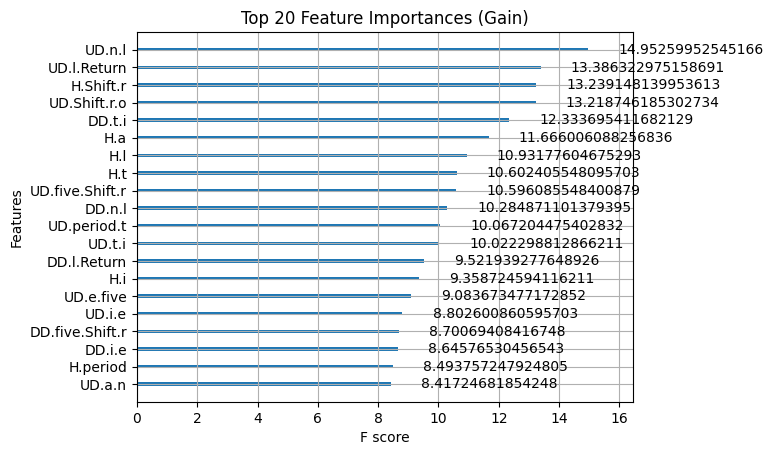

In [10]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb, importance_type='gain', max_num_features=20)
plt.title("Top 20 Feature Importances (Gain)")
plt.show()

## Using only Top N Features

In [11]:
top_features = [
    'UD.n.l', 'UD.l.Return', 'H.Shift.r', 'UD.Shift.r.o', 'DD.t.i',
    'H.a', 'H.l', 'H.t', 'UD.five.Shift.r', 'DD.n.l',
    'UD.period.t', 'UD.t.i', 'DD.l.Return', 'H.i', 'UD.e.five',
    'UD.i.e', 'DD.five.Shift.r', 'DD.i.e', 'H.period', 'UD.a.n'
]

X_top = df[top_features]
y = le.fit_transform(df['subject'])

X_train, X_test, y_train, y_test = train_test_split(X_top, y, test_size=0.2, random_state=42, stratify=y)

## Tuning Regularization Parameters

In [12]:
xgb = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,   # Increased L1 regularization
    reg_lambda=2.0,  # Increased L2 regularization
    use_label_encoder=False,
    eval_metric='mlogloss'
)

In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# Split your training data into a new train/validation set for early stopping
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train_encoded, test_size=0.2, stratify=y_train_encoded, random_state=42
)

# XGBoost model with manual tuning (from your setup)
xgb = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train with early stopping
xgb.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=20,
    verbose=True
)

[0]	validation_0-mlogloss:3.45899
[1]	validation_0-mlogloss:3.16035


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[2]	validation_0-mlogloss:2.94400
[3]	validation_0-mlogloss:2.76696
[4]	validation_0-mlogloss:2.61810
[5]	validation_0-mlogloss:2.48772
[6]	validation_0-mlogloss:2.37537
[7]	validation_0-mlogloss:2.27556
[8]	validation_0-mlogloss:2.18794
[9]	validation_0-mlogloss:2.10452
[10]	validation_0-mlogloss:2.02905
[11]	validation_0-mlogloss:1.96145
[12]	validation_0-mlogloss:1.89722
[13]	validation_0-mlogloss:1.83620
[14]	validation_0-mlogloss:1.77967
[15]	validation_0-mlogloss:1.72715
[16]	validation_0-mlogloss:1.67870
[17]	validation_0-mlogloss:1.63164
[18]	validation_0-mlogloss:1.58718
[19]	validation_0-mlogloss:1.54580
[20]	validation_0-mlogloss:1.50621
[21]	validation_0-mlogloss:1.46879
[22]	validation_0-mlogloss:1.43281
[23]	validation_0-mlogloss:1.39799
[24]	validation_0-mlogloss:1.36486
[25]	validation_0-mlogloss:1.33357
[26]	validation_0-mlogloss:1.30363
[27]	validation_0-mlogloss:1.27504
[28]	validation_0-mlogloss:1.24820
[29]	validation_0-mlogloss:1.22219
[30]	validation_0-mlogloss:1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

## Model Evaluation on Test Data

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))

Accuracy: 0.9107843137254902
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82        80
           1       0.94      0.93      0.93        80
           2       0.87      0.85      0.86        80
           3       0.88      0.94      0.91        80
           4       0.81      0.89      0.85        80
           5       0.81      0.76      0.79        80
           6       0.99      0.96      0.97        80
           7       0.96      0.81      0.88        80
           8       0.90      0.91      0.91        80
           9       0.96      0.90      0.93        80
          10       0.94      0.90      0.92        80
          11       0.94      0.96      0.95        80
          12       0.98      1.00      0.99        80
          13       0.97      0.82      0.89        80
          14       1.00      1.00      1.00        80
          15       0.89      0.85      0.87        80
          16       0.89     

## Feature Importance Plot

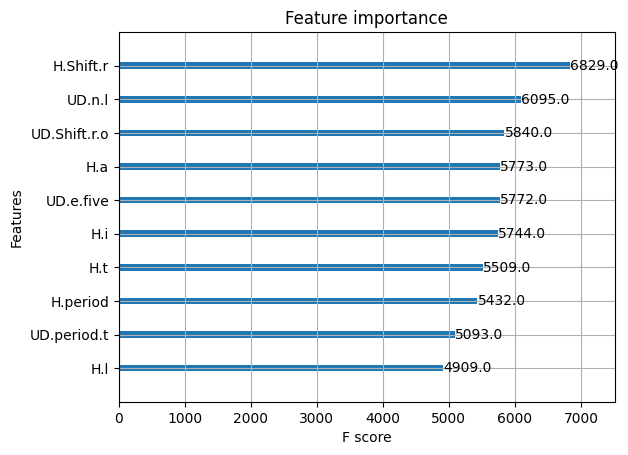

In [15]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb, max_num_features=10)
plt.show()

## Early stopping - Future Model Tuning

In [16]:
xgb = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=200,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.5,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb.fit(
    X_train, y_train_encoded,
    eval_set=[(X_test, y_test_encoded)],
    early_stopping_rounds=10,
    verbose=True
)

[0]	validation_0-mlogloss:3.44055


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[1]	validation_0-mlogloss:3.14215
[2]	validation_0-mlogloss:2.92746
[3]	validation_0-mlogloss:2.74743
[4]	validation_0-mlogloss:2.59931
[5]	validation_0-mlogloss:2.46874
[6]	validation_0-mlogloss:2.35431
[7]	validation_0-mlogloss:2.25484
[8]	validation_0-mlogloss:2.16561
[9]	validation_0-mlogloss:2.08294
[10]	validation_0-mlogloss:2.00800
[11]	validation_0-mlogloss:1.93746
[12]	validation_0-mlogloss:1.87361
[13]	validation_0-mlogloss:1.81305
[14]	validation_0-mlogloss:1.75683
[15]	validation_0-mlogloss:1.70396
[16]	validation_0-mlogloss:1.65383
[17]	validation_0-mlogloss:1.60613
[18]	validation_0-mlogloss:1.56219
[19]	validation_0-mlogloss:1.51880
[20]	validation_0-mlogloss:1.47830
[21]	validation_0-mlogloss:1.44051
[22]	validation_0-mlogloss:1.40428
[23]	validation_0-mlogloss:1.36946
[24]	validation_0-mlogloss:1.33690
[25]	validation_0-mlogloss:1.30529
[26]	validation_0-mlogloss:1.27523
[27]	validation_0-mlogloss:1.24688
[28]	validation_0-mlogloss:1.21866
[29]	validation_0-mlogloss:1.

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

## Save the Model

In [17]:
import joblib
joblib.dump(xgb, 'xgb_typing_model.pkl')

['xgb_typing_model.pkl']

## Heatmap of Feature Correlation

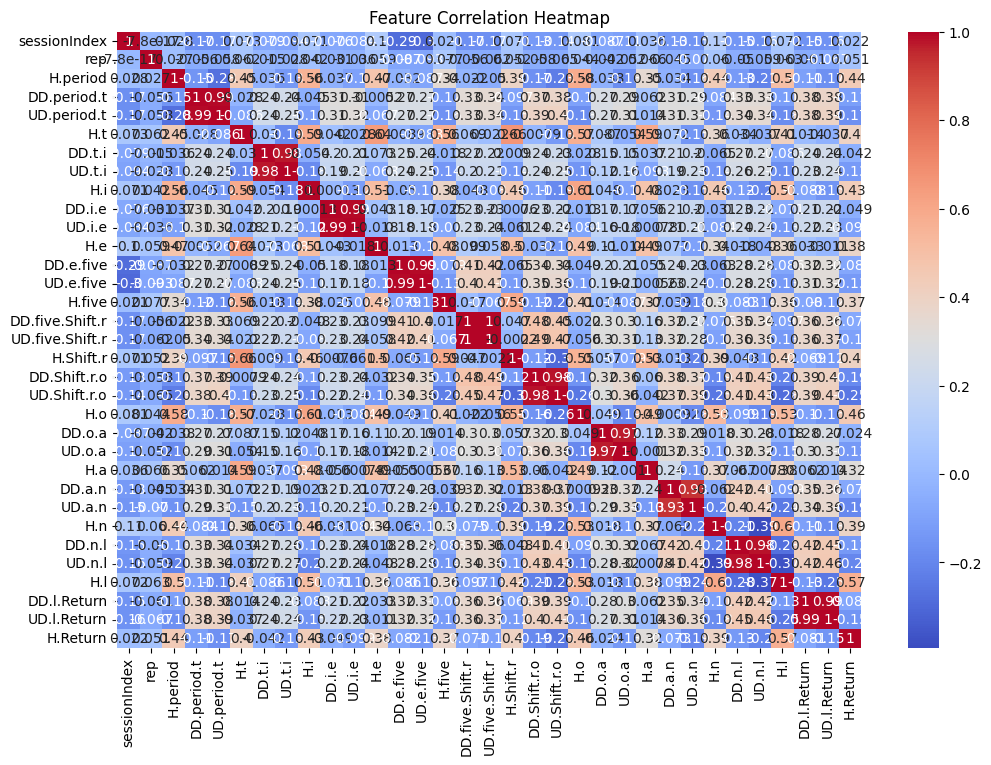

In [18]:
# Drop non-numeric columns before computing correlation
numeric_df = df.select_dtypes(include='number')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## Confusion Matrix Heatmap

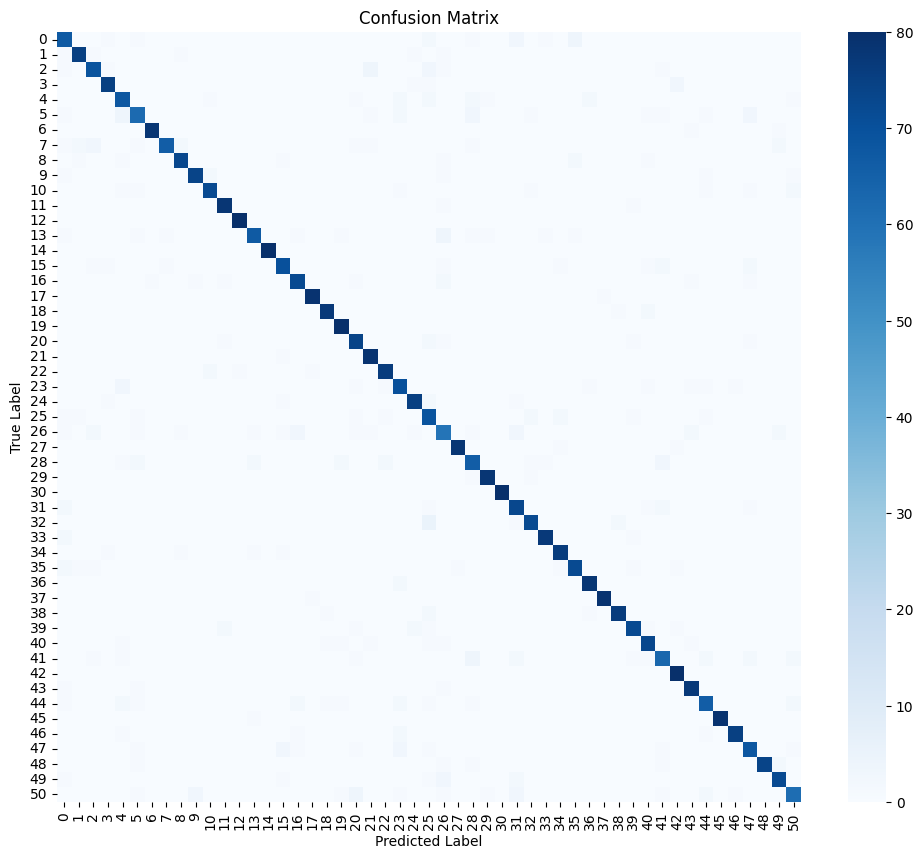

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predictions
y_pred = xgb.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", annot=False, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Final Evaluation Metrics

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9139705882352941

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82        80
           1       0.94      0.94      0.94        80
           2       0.88      0.86      0.87        80
           3       0.94      0.94      0.94        80
           4       0.82      0.85      0.83        80
           5       0.83      0.78      0.80        80
           6       0.99      0.97      0.98        80
           7       0.97      0.82      0.89        80
           8       0.94      0.91      0.92        80
           9       0.95      0.93      0.94        80
          10       0.94      0.90      0.92        80
          11       0.95      0.97      0.96        80
          12       0.99      1.00      0.99        80
          13       0.93      0.84      0.88        80
          14       1.00      1.00      1.00        80
          15       0.89      0.88      0.88        80
          16       0.90    

# Conclusion

XGBoost achieved 91% accuracy across 50 users in the keystroke dynamics dataset.

Most users are classified with precision and recall above 0.9, showing strong discriminative power.

A few subjects (like class 25 & 26) had lower F1-scores (~0.73–0.77), suggesting individual differences in typing patterns.

Overall, XGBoost performs well for multi-class keystroke authentication. Future improvements could explore deep learning (RNNs/LSTMs) or cross-session validation for robustness.

## Baseline Model Comparison

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

for model, name in [(lr, "Logistic Regression"), (rf, "Random Forest")]:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, preds))

Logistic Regression Accuracy: 0.6595588235294118
Random Forest Accuracy: 0.9095588235294118


## Per User Plot

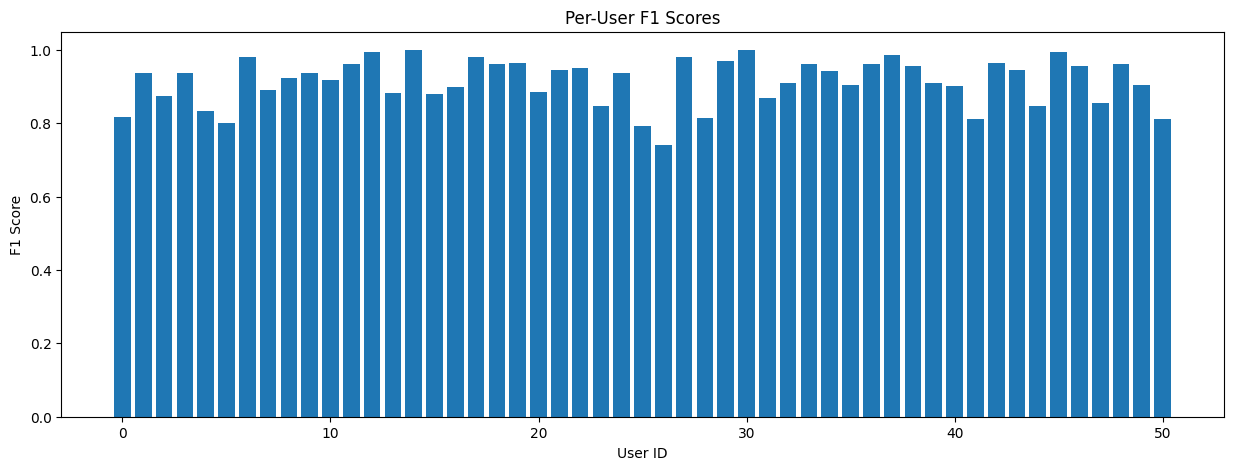

In [22]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

precisions, recalls, f1s, _ = precision_recall_fscore_support(y_test, y_pred)
plt.figure(figsize=(15,5))
plt.bar(range(len(f1s)), f1s)
plt.title("Per-User F1 Scores")
plt.xlabel("User ID")
plt.ylabel("F1 Score")
plt.show()